In [1]:
import random
import numpy as np
from matplotlib import pyplot as plt
from scipy.special import erf

In [2]:
#EJERCICIO 1 - Integración de Monte Carlo

def aproximacion_integral(f, a, b, n):
    h = (b - a) / n
    x_i = np.random.uniform(a, b, n)
    return h * np.sum(f(x_i))



# EJERCICIO 2

funciones = [
    (lambda x: x**2,      0, 1,      1/3,       "x²"),
    (lambda x: np.sin(x), 0, np.pi,  2.0,       "sin(x)"),
    (lambda x: np.exp(x), 0, 1,      np.e - 1,  "e^x"),
]
n = 10000

for f, a, b, exacto, nombre in funciones:
    aprox = aproximacion_integral(f, a, b, n)
    error = abs(aprox - exacto)
    print(f"∫{nombre}: aprox = {aprox:.5f}, exacto = {exacto:.5f}, error = {error:.5f}")


∫x²: aprox = 0.33534, exacto = 0.33333, error = 0.00200
∫sin(x): aprox = 2.00964, exacto = 2.00000, error = 0.00964
∫e^x: aprox = 1.72239, exacto = 1.71828, error = 0.00410


In [3]:
# EJERCICIO 3

def ejecutar_varias_veces(f, a, b, n, i):
    resultados = []
    for _ in range(i):
        resultado = aproximacion_integral(f, a, b, n)
        resultados.append(resultado)
    return resultados

def calcular_estadisticas(resultados):
    media = np.mean(resultados)
    varianza_muestral = np.var(resultados, ddof=1)
    return media, varianza_muestral

# Ejemplo: x² dx de 0 a 1 con n=10000, ejecutado 10 veces
f = lambda x: x**2
a3 = 0
b3 = 1
n3 = 10000
veces = 10
resultados = ejecutar_varias_veces(f, a3, b3, n3, veces)
media, varianza = calcular_estadisticas(resultados)
print(f"Resultados de ejecutar la aproximación de la integral en {veces} veces")
for idx, res in enumerate(resultados, 1):
    print(f"Ejecutación {idx}: Aproximación = {res}")
    
print(f"Media: {media}, Varianza: {varianza}")


Resultados de ejecutar la aproximación de la integral en 10 veces
Ejecutación 1: Aproximación = 0.33608875122824705
Ejecutación 2: Aproximación = 0.33291329937305797
Ejecutación 3: Aproximación = 0.32322306667492223
Ejecutación 4: Aproximación = 0.3309510654648279
Ejecutación 5: Aproximación = 0.33229632058865627
Ejecutación 6: Aproximación = 0.3319599634866249
Ejecutación 7: Aproximación = 0.33196825098805366
Ejecutación 8: Aproximación = 0.3356403886392889
Ejecutación 9: Aproximación = 0.3343514988521587
Ejecutación 10: Aproximación = 0.33514023788264896
Media: 0.3324532843178486, Varianza: 1.35961827716664e-05


In [4]:
#EJERCICIO 4, 5
for n_test in [100, 1000, 10000, 100000]:
    resultados_test = ejecutar_varias_veces(f, a3, b3, n_test, 50)
    media_test, varianza_test = calcular_estadisticas(resultados_test)
    print(f"n={n_test}: media={media_test:.5f}, varianza={varianza_test:.8f}")

print("Se observa que al aumentar n, la varianza disminuye significativamente")

n=100: media=0.33748, varianza=0.00095088
n=1000: media=0.33494, varianza=0.00009492
n=10000: media=0.33365, varianza=0.00001042
n=100000: media=0.33324, varianza=0.00000071
Se observa que al aumentar n, la varianza disminuye significativamente


In [5]:
#EJERCICIO 6
f6 = lambda x: 4 * np.sqrt(1 - x**2)

a6, b6 = 0, 1
valor_exacto = np.pi
valores_n = sorted(m * 10**i for i in range(1, 7) for m in (1, 5))
aproximaciones = []
errores = []
for n6 in valores_n:
    # usamos media de 30 ejecuciones para suavizar la aleatoriedad
    muestra = [aproximacion_integral(f6, a6, b6, n6) for _ in range(30)]
    resultado = np.mean(muestra)
    error = abs(resultado - valor_exacto)
    aproximaciones.append(resultado)
    errores.append(error)
    print(f"Resultado: {resultado:.10f} para n={n6}, error absoluto: {error:.6f}, error relativo: {error/valor_exacto:.6f}")






Resultado: 3.0904514263 para n=10, error absoluto: 0.051141, error relativo: 0.016279
Resultado: 3.1349424993 para n=50, error absoluto: 0.006650, error relativo: 0.002117
Resultado: 3.1210168195 para n=100, error absoluto: 0.020576, error relativo: 0.006549
Resultado: 3.1416890809 para n=500, error absoluto: 0.000096, error relativo: 0.000031
Resultado: 3.1433515512 para n=1000, error absoluto: 0.001759, error relativo: 0.000560
Resultado: 3.1417590255 para n=5000, error absoluto: 0.000166, error relativo: 0.000053
Resultado: 3.1409550090 para n=10000, error absoluto: 0.000638, error relativo: 0.000203
Resultado: 3.1414777870 para n=50000, error absoluto: 0.000115, error relativo: 0.000037
Resultado: 3.1418680643 para n=100000, error absoluto: 0.000275, error relativo: 0.000088
Resultado: 3.1419148842 para n=500000, error absoluto: 0.000322, error relativo: 0.000103
Resultado: 3.1415544320 para n=1000000, error absoluto: 0.000038, error relativo: 0.000012
Resultado: 3.1415369371 para 

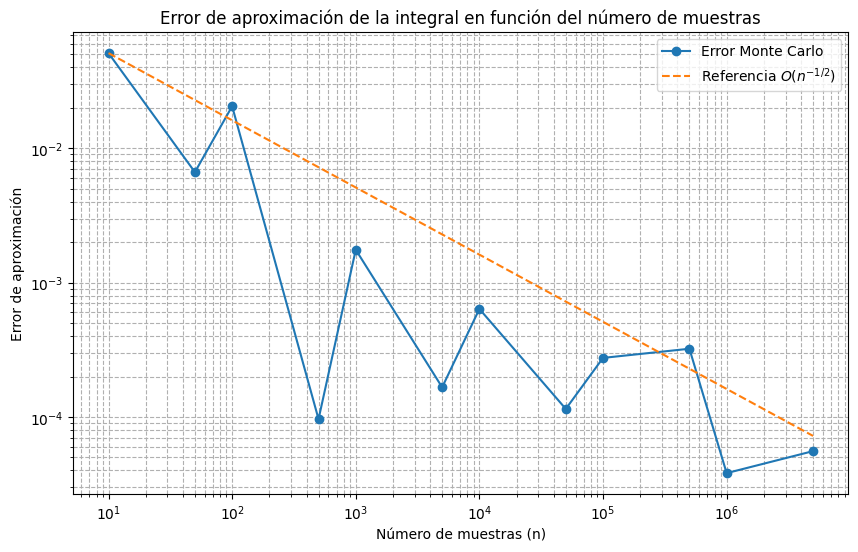

In [6]:
# EJERCICIO 7

def representar_errores(valores_n, errores):
    referencia = [errores[0] * (valores_n[0]/n)**0.5 for n in valores_n]
    plt.figure(figsize=(10,6))
    plt.plot(valores_n, errores, marker='o', label='Error Monte Carlo')
    plt.plot(valores_n, referencia, '--', label=r'Referencia $O(n^{-1/2})$')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Número de muestras (n)')
    plt.ylabel('Error de aproximación')
    plt.title('Error de aproximación de la integral en función del número de muestras')
    plt.legend()
    plt.grid(True, which="both", ls="--")
    plt.show()

representar_errores(valores_n, errores)

In [7]:
# EJERCICIO 8

#para obtener el orden de convergencia, queremos verificar si el error se comporta con O(n^(-1/2)) por tanto con pendiente -1/2.
#analizando la pendiente entre cada par de puntos consecutivos de valores_n, error, en forma logarítmica

# error = c * n ^(-1/2)
# log(error) = log(c) + -1/2 * log(n)
# y que es una funcion y = mx + b siendo m la pendiente (-1/2) que queremos estimar

errores8 = []
for n8 in valores_n:
    muestra = [abs(aproximacion_integral(f6, a6, b6, n8) - valor_exacto) for _ in range(30)]
    errores8.append(np.mean(muestra))

pendientes = []
for i in range(len(errores8)-1):
    num = np.log(errores8[i+1]) - np.log(errores8[i])
    den = np.log(valores_n[i+1]) - np.log(valores_n[i])
    pendientes.append(num/den)

print(f"Pendientes estimadas: {[round(p, 3) for p in pendientes]}")
print(f"Pendiente media: {round(np.mean(pendientes), 3)}")
print("Valor teórico esperado: -0.500")

Pendientes estimadas: [np.float64(-0.757), np.float64(-0.075), np.float64(-0.585), np.float64(-0.252), np.float64(-0.599), np.float64(-0.545), np.float64(-0.48), np.float64(-0.329), np.float64(-0.673), np.float64(-0.465), np.float64(-0.533)]
Pendiente media: -0.481
Valor teórico esperado: -0.500


In [8]:
# EJERCICIO 9
# Genera n puntos aleatorios uniformes en el rectángulo [a, b] × [0, M]
def puntos_aleatorio_rectangulo(a, b, M, n):
    x = np.random.uniform(a, b, n)
    y = np.random.uniform(0, M, n)
    return np.column_stack((x, y))


# EJERCICIO 10
# Determina qué puntos satisfacen y ≤ f(x) y aproxima el área bajo la curva
def puntos_validos(f, puntos):
    x = puntos[:,0]
    y = puntos[:,1]
    mask = y <= f(x)
    return puntos[mask]

def proporcion(f, a, b, M, n):
    puntos = puntos_aleatorio_rectangulo(a, b, M, n)
    x = puntos[:,0]
    y = puntos[:,1]
    return np.sum(y <= f(x)) / n

def integracion_area_bajo_curva(f, a, b, M, n):
    p = proporcion(f, a, b, M, n)
    return p * (b - a) * M


#EJERCICIO 11
funciones11 = [
    (lambda x: x**2,      0, 1,      1,    1/3,       "x²"),
    (lambda x: np.sin(x), 0, np.pi,  1,    2.0,       "sin(x)"),
    (lambda x: np.exp(x), 0, 1,      np.e, np.e - 1,  "e^x"),
]

n11 = 100000
for f, a, b, M, exacto, nombre in funciones11:
    area = integracion_area_bajo_curva(f, a, b, M, n11)
    error = abs(area - exacto)
    print(f"∫{nombre}: área = {area:.5f}, exacto = {exacto:.5f}, error = {error:.5f}")


∫x²: área = 0.33090, exacto = 0.33333, error = 0.00243
∫sin(x): área = 2.00371, exacto = 2.00000, error = 0.00371
∫e^x: área = 1.71937, exacto = 1.71828, error = 0.00109


In [9]:
#EJERCICIO 12
sigma = 0.05
f12 = lambda x: np.exp(-x**2 / (2 * sigma**2))

a12, b12 = -1, 1
M12 = 1 #máximo de f12, ya que exp(0) = 1

# Valor exacto de la integral en [-1, 1] (no en todo R):
# ∫_{-1}^{1} exp(-x²/(2σ²)) dx = σ√(2π) · erf(1/(σ√2))
valor_exacto_12 = sigma * np.sqrt(2 * np.pi) * erf(1 / (sigma * np.sqrt(2)))

n12 = 10000
aprox12 = aproximacion_integral(f12, a12, b12, n12)
print(f"Aproximación: {aprox12:.5f}, valor exacto (en [-1,1]): {valor_exacto_12:.5f}")
print(f"Nota: σ√(2π) = {sigma * np.sqrt(2 * np.pi):.5f} (integral en todo R)")
print(f"La diferencia es despreciable porque la función está muy concentrada en torno a x=0")


Aproximación: 0.12856, valor exacto (en [-1,1]): 0.12533
Nota: σ√(2π) = 0.12533 (integral en todo R)
La diferencia es despreciable porque la función está muy concentrada en torno a x=0


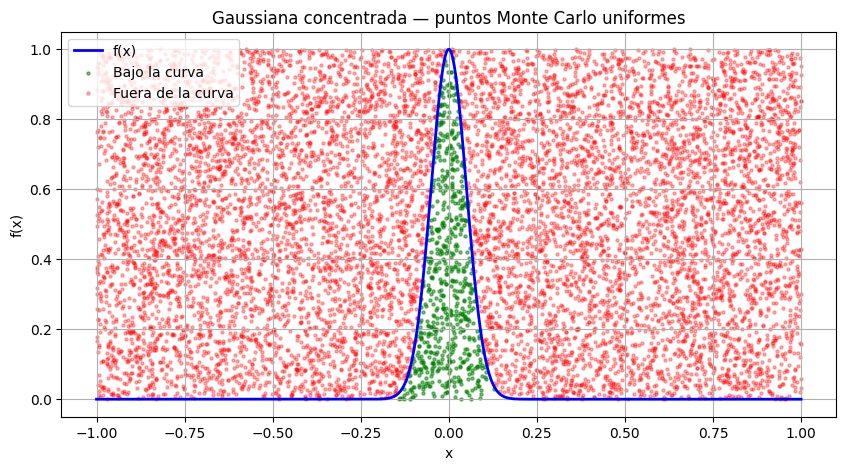

Ejercicio 13: Representación gráfica de la función y los puntos aleatorios
Se generan 10000 puntos aleatorios uniformes en el rectángulo [-1, 1] x [0, 1]
Se puede observar que la mayoría de los puntos caen fuera del pico de la función
lo que significa que el método uniforme es muy ineficiente para funciones con picos estrechos


In [10]:
# EJERCICIO 13
x_plot = np.linspace(a12, b12, 1000)
x_muestra = np.random.uniform(a12, b12, n12)
y_muestra = np.random.uniform(0, M12, n12)
bajo_curva = y_muestra <= f12(x_muestra)

plt.figure(figsize=(10, 5))
plt.plot(x_plot, f12(x_plot), 'b-', label='f(x)', linewidth=2)
plt.scatter(x_muestra[bajo_curva],  y_muestra[bajo_curva],  
            alpha=0.5, s=5, color='green', label='Bajo la curva')
plt.scatter(x_muestra[~bajo_curva], y_muestra[~bajo_curva], 
            alpha=0.3, s=5, color='red',   label='Fuera de la curva')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Gaussiana concentrada — puntos Monte Carlo uniformes')
plt.legend()
plt.grid(True)
plt.show()


print("Ejercicio 13: Representación gráfica de la función y los puntos aleatorios")
print(f"Se generan {n12} puntos aleatorios uniformes en el rectángulo [{a12}, {b12}] x [0, {M12}]")
print("Se puede observar que la mayoría de los puntos caen fuera del pico de la función")
print("lo que significa que el método uniforme es muy ineficiente para funciones con picos estrechos")

n=     10: aprox media=0.184893, error medio=0.138285
n=     50: aprox media=0.115589, error medio=0.040662
n=    100: aprox media=0.120340, error medio=0.031758
n=    500: aprox media=0.118448, error medio=0.013233
n=   1000: aprox media=0.124880, error medio=0.009721
n=   5000: aprox media=0.126701, error medio=0.005092
n=  10000: aprox media=0.124362, error medio=0.003626
n=  50000: aprox media=0.125866, error medio=0.001379
n= 100000: aprox media=0.125489, error medio=0.001002
n= 500000: aprox media=0.125313, error medio=0.000284
n=1000000: aprox media=0.125386, error medio=0.000325
n=5000000: aprox media=0.125295, error medio=0.000174


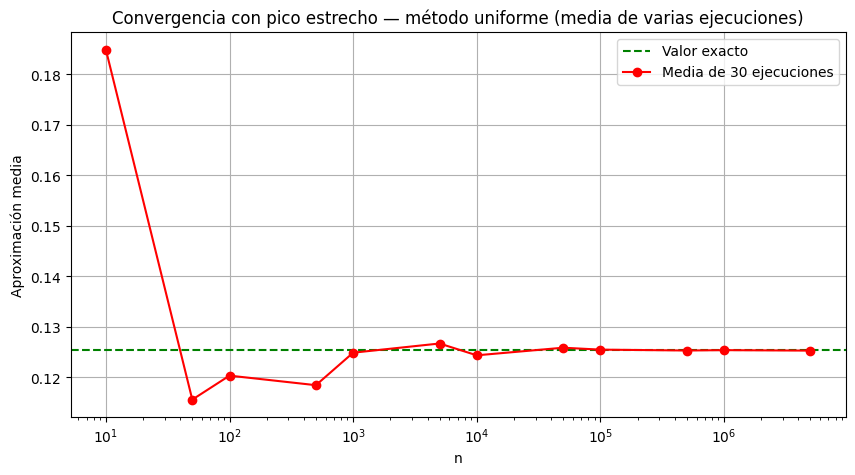


Ejercicio 14: Convergencia del método uniforme con pico estrecho
Valor exacto (en [-1,1]): 0.12533
Se promedian 30 ejecuciones para cada n, lo que suaviza la aleatoriedad.
Se observa que para n pequeño el error medio es muy grande
y que solo para n muy grande empieza a converger al valor exacto,
lo que confirma que el método uniforme es muy ineficiente para funciones con picos estrechos.


In [11]:
# EJERCICIO 14
# Repetimos el experimento varias veces para cada n y usamos el error medio

valores_n14 = sorted(m * 10**i for i in range(1, 7) for m in (1, 5))
errores_medios14 = []
aproximaciones_medias14 = []
n_repeticiones = 30

for n14 in valores_n14:
    resultados = [aproximacion_integral(f12, a12, b12, n14) for _ in range(n_repeticiones)]
    media = np.mean(resultados)
    error_medio = np.mean([abs(r - valor_exacto_12) for r in resultados])
    aproximaciones_medias14.append(media)
    errores_medios14.append(error_medio)
    print(f"n={n14:7d}: aprox media={media:.6f}, error medio={error_medio:.6f}")

plt.figure(figsize=(10, 5))
plt.axhline(y=valor_exacto_12, color='green', linestyle='--', label='Valor exacto')
plt.plot(valores_n14, aproximaciones_medias14, 'o-', color='red', label=f'Media de {n_repeticiones} ejecuciones')
plt.xscale('log')
plt.xlabel('n')
plt.ylabel('Aproximación media')
plt.title('Convergencia con pico estrecho — método uniforme (media de varias ejecuciones)')
plt.legend()
plt.grid(True)
plt.show()

print("\nEjercicio 14: Convergencia del método uniforme con pico estrecho")
print(f"Valor exacto (en [-1,1]): {valor_exacto_12:.5f}")
print(f"Se promedian {n_repeticiones} ejecuciones para cada n, lo que suaviza la aleatoriedad.")
print("Se observa que para n pequeño el error medio es muy grande")
print("y que solo para n muy grande empieza a converger al valor exacto,")
print("lo que confirma que el método uniforme es muy ineficiente para funciones con picos estrechos.")


In [ ]:
# EJERCICIO 15 — Importance sampling
# Programa que implementa el método de importance sampling para una densidad rho(x) dada.
# La fórmula es: integral ≈ (1/n) * sum( f(xi) / rho(xi) ) donde xi ~ rho

def importance_sampling(f, rho, generar_muestras, n):

    """
    Aproxima la integral de f usando importance sampling.
    Args:
        f: función a integrar
        rho: densidad de probabilidad usada para el muestreo
        generar_muestras: función que genera n muestras según la densidad rho
        n: número de muestras
    Returns:
        Aproximación de la integral de f
    """

    x = generar_muestras(n)
    return np.mean(f(x) / rho(x))

# Verificación rápida con un caso conocido: ∫₀¹ x² dx = 1/3
# Usamos como densidad rho(x) = 2x en [0,1] (cuya CDF inversa es sqrt(U))
f_test = lambda x: x**2
rho_test = lambda x: 2 * x
gen_test = lambda n: np.sqrt(np.random.uniform(0, 1, n))  # muestras según rho=2x

aprox_is = importance_sampling(f_test, rho_test, gen_test, 100000)
print(f"Verificación importance sampling: ∫₀¹ x² dx")
print(f"Aproximación = {aprox_is:.5f}, exacto = {1/3:.5f}, error = {abs(aprox_is - 1/3):.5f}")


Verificación importance sampling: ∫₀¹ x² dx
Aproximación = 0.33371, exacto = 0.33333, error = 0.00038


       n     MC uniforme    err unif   Importance S.      err IS
-----------------------------------------------------------------
      10        0.158496    0.098885        0.125331    0.000000
      50        0.143777    0.054119        0.125331    0.000000
     100        0.106176    0.035701        0.125331    0.000000
     500        0.125965    0.013703        0.125331    0.000000
    1000        0.123728    0.009033        0.125331    0.000000
    5000        0.125205    0.004202        0.125331    0.000000
   10000        0.125590    0.003299        0.125331    0.000000
   50000        0.125257    0.001264        0.125331    0.000000
  100000        0.125488    0.000883        0.125331    0.000000
  500000        0.125250    0.000488        0.125331    0.000000


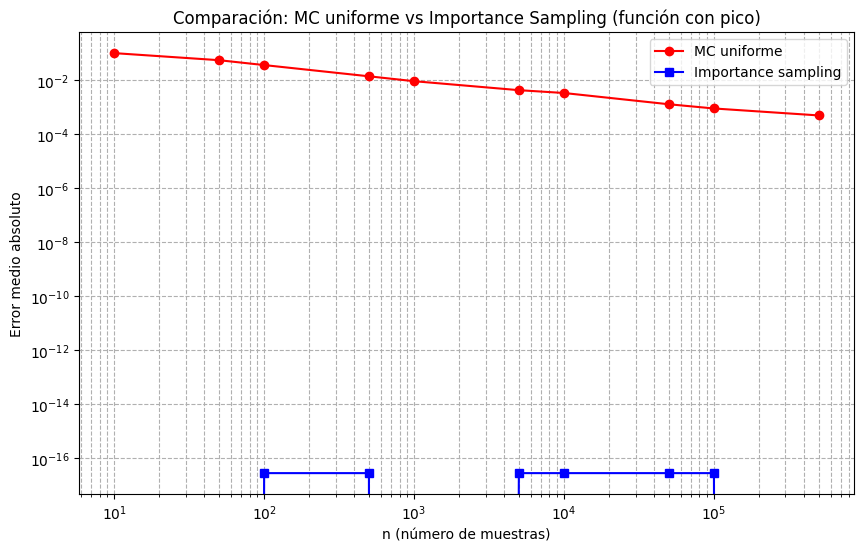


Conclusión: El importance sampling reduce drásticamente el error.
De hecho, el error del IS es prácticamente nulo. Esto se debe a que la densidad
de muestreo elegida (gaussiana con σ=0.05) es proporcional a la propia función f(x),
ya que f(x) = exp(-x²/(2σ²)) y ρ(x) = exp(-x²/(2σ²)) / Z.
Por tanto, el cociente f(x)/ρ(x) = Z (constante), y la varianza del estimador es cero.
Este es el caso ideal del importance sampling: cuando ρ ∝ f, la estimación es exacta.


In [13]:
# EJERCICIO 16 — Importance sampling aplicado a la función con pico estrecho
# Comparación con el método Monte Carlo uniforme

# Función con pico del ejercicio 12: f(x) = exp(-x²/(2σ²)), σ=0.05, en [-1,1]
# Valor exacto en [-1,1]: σ√(2π)·erf(1/(σ√2)) ≈ 0.12533

# Densidad para importance sampling: usamos una gaussiana centrada en 0
# con desviación típica σ_is = 0.05 (similar al pico), truncada en [-1,1]
sigma_is = 0.05

# Constante de normalización de la gaussiana truncada en [-1,1]
Z_is = sigma_is * np.sqrt(2 * np.pi) * (erf(1 / (sigma_is * np.sqrt(2))) )

rho_gauss = lambda x: np.exp(-x**2 / (2 * sigma_is**2)) / Z_is

def generar_gauss_truncada(n):
    """Genera muestras de una gaussiana N(0, sigma_is²) truncada en [-1,1]"""
    muestras = []
    while len(muestras) < n:
        candidatas = np.random.normal(0, sigma_is, n - len(muestras) + 1000)
        validas = candidatas[(candidatas >= a12) & (candidatas <= b12)]
        muestras.extend(validas.tolist())
    return np.array(muestras[:n])

# Comparación para distintos valores de n
valores_n16 = sorted(m * 10**i for i in range(1, 6) for m in (1, 5))

errores_uniforme = []
errores_is = []

print(f"{'n':>8}  {'MC uniforme':>14}  {'err unif':>10}  {'Importance S.':>14}  {'err IS':>10}")
print("-" * 65)

for n16 in valores_n16:
    # Media de 30 ejecuciones para suavizar
    res_unif = [aproximacion_integral(f12, a12, b12, n16) for _ in range(30)]
    res_is   = [importance_sampling(f12, rho_gauss, generar_gauss_truncada, n16) for _ in range(30)]
    
    err_u = np.mean([abs(r - valor_exacto_12) for r in res_unif])
    err_i = np.mean([abs(r - valor_exacto_12) for r in res_is])
    
    errores_uniforme.append(err_u)
    errores_is.append(err_i)
    
    print(f"{n16:8d}  {np.mean(res_unif):14.6f}  {err_u:10.6f}  {np.mean(res_is):14.6f}  {err_i:10.6f}")

# Gráfica comparativa
plt.figure(figsize=(10, 6))
plt.plot(valores_n16, errores_uniforme, 'o-', color='red', label='MC uniforme')
plt.plot(valores_n16, errores_is, 's-', color='blue', label='Importance sampling')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('n (número de muestras)')
plt.ylabel('Error medio absoluto')
plt.title('Comparación: MC uniforme vs Importance Sampling (función con pico)')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.show()

print("\nConclusión: El importance sampling reduce drásticamente el error.")
print("De hecho, el error del IS es prácticamente nulo. Esto se debe a que la densidad")
print("de muestreo elegida (gaussiana con σ=0.05) es proporcional a la propia función f(x),")
print("ya que f(x) = exp(-x²/(2σ²)) y ρ(x) = exp(-x²/(2σ²)) / Z.")
print("Por tanto, el cociente f(x)/ρ(x) = Z (constante), y la varianza del estimador es cero.")
print("Este es el caso ideal del importance sampling: cuando ρ ∝ f, la estimación es exacta.")


Valor exacto (cuadratura): 2.09275004

MC uniforme (n=100000, media de 30 ejec.): 2.093623, error medio = 0.005107

    σ²      σ      Aprox IS      Error IS    Error unif
--------------------------------------------------------
  0.25   0.50      2.089659      0.006527      0.005107
  1.00   1.00      2.091522      0.002427      0.005107
  2.25   1.50      2.092824      0.002821      0.005107
  4.00   2.00      2.093237      0.004107      0.005107
  9.00   3.00      2.092351      0.005153      0.005107


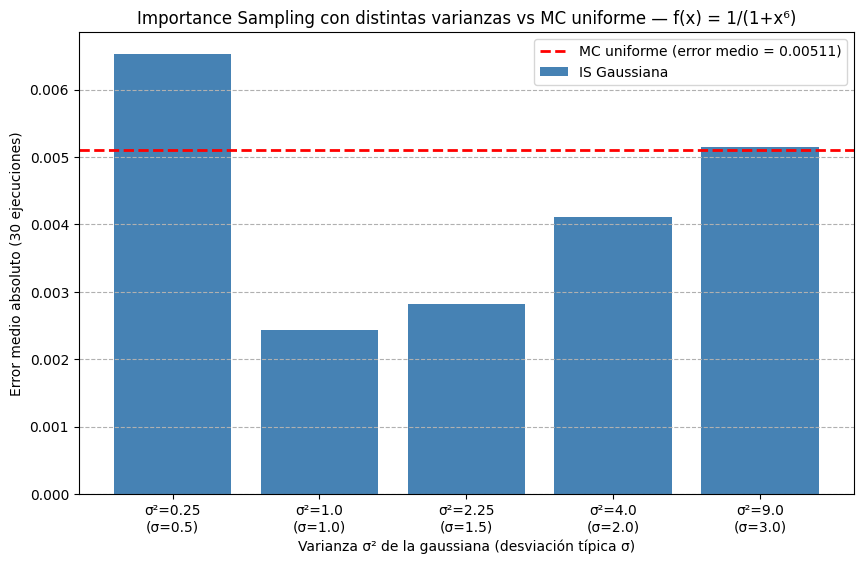


Conclusión: La gaussiana con σ² ≈ 1.0 (σ ≈ 1.0) da los mejores resultados,
ya que se adapta bien a la forma de f(x) = 1/(1+x⁶), que tiene la mayor
parte de su área concentrada alrededor de x=0 pero con colas moderadas.
σ² muy pequeña concentra demasiado las muestras y desaprovecha las colas,
mientras que σ² muy grande dispersa las muestras y se comporta como la uniforme.


In [14]:
# EJERCICIO 17 — f(x) = 1/(1+x⁶) en [-3,3], uniforme vs gaussiana con distintas varianzas

from scipy.integrate import quad
from scipy.stats import norm

f17 = lambda x: 1 / (1 + x**6)
a17, b17 = -3, 3

# Valor exacto (referencia numérica)
valor_exacto_17, _ = quad(f17, a17, b17)
print(f"Valor exacto (cuadratura): {valor_exacto_17:.8f}\n")

# --- Método uniforme (media de 30 ejecuciones) ---
n17 = 100000
res_unif_17 = [aproximacion_integral(f17, a17, b17, n17) for _ in range(30)]
err_unif_medio = np.mean([abs(r - valor_exacto_17) for r in res_unif_17])
print(f"MC uniforme (n={n17}, media de 30 ejec.): {np.mean(res_unif_17):.6f}, error medio = {err_unif_medio:.6f}")

# --- Importance sampling con gaussiana N(0, σ²) truncada en [-3,3] ---
# El enunciado pide probar distintos valores de la varianza σ².
# Usamos las siguientes varianzas (y sus desviaciones típicas correspondientes):
varianzas_17 = [0.25, 1.0, 2.25, 4.0, 9.0]  # σ² = 0.25, 1, 2.25, 4, 9
sigmas_17 = [np.sqrt(v) for v in varianzas_17]  # σ = 0.5, 1.0, 1.5, 2.0, 3.0

print(f"\n{'σ²':>6}  {'σ':>5}  {'Aprox IS':>12}  {'Error IS':>12}  {'Error unif':>12}")
print("-" * 56)

errores_sigma = []

for var17, sig in zip(varianzas_17, sigmas_17):
    # Constante de normalización de la gaussiana truncada en [-3,3]
    Z17 = norm.cdf(b17, 0, sig) - norm.cdf(a17, 0, sig)
    
    rho17 = lambda x, s=sig, z=Z17: norm.pdf(x, 0, s) / z
    
    def gen_gauss17(n, s=sig):
        muestras = []
        while len(muestras) < n:
            candidatas = np.random.normal(0, s, n - len(muestras) + 2000)
            validas = candidatas[(candidatas >= a17) & (candidatas <= b17)]
            muestras.extend(validas.tolist())
        return np.array(muestras[:n])
    
    # Media de 30 ejecuciones
    res_is17 = [importance_sampling(f17, rho17, gen_gauss17, n17) for _ in range(30)]
    media_is = np.mean(res_is17)
    err_is = np.mean([abs(r - valor_exacto_17) for r in res_is17])
    errores_sigma.append(err_is)
    
    print(f"{var17:6.2f}  {sig:5.2f}  {media_is:12.6f}  {err_is:12.6f}  {err_unif_medio:12.6f}")

# Gráfica
plt.figure(figsize=(10, 6))
etiquetas = [f"σ²={v}\n(σ={s:.1f})" for v, s in zip(varianzas_17, sigmas_17)]
plt.bar(etiquetas, errores_sigma, color='steelblue', label='IS Gaussiana')
plt.axhline(y=err_unif_medio, color='red', linestyle='--', linewidth=2,
            label=f'MC uniforme (error medio = {err_unif_medio:.5f})')
plt.xlabel('Varianza σ² de la gaussiana (desviación típica σ)')
plt.ylabel('Error medio absoluto (30 ejecuciones)')
plt.title('Importance Sampling con distintas varianzas vs MC uniforme — f(x) = 1/(1+x⁶)')
plt.legend()
plt.grid(True, axis='y', ls='--')
plt.show()

print("\nConclusión: La gaussiana con σ² ≈ 1.0 (σ ≈ 1.0) da los mejores resultados,")
print("ya que se adapta bien a la forma de f(x) = 1/(1+x⁶), que tiene la mayor")
print("parte de su área concentrada alrededor de x=0 pero con colas moderadas.")
print("σ² muy pequeña concentra demasiado las muestras y desaprovecha las colas,")
print("mientras que σ² muy grande dispersa las muestras y se comporta como la uniforme.")


       n      Error MC   Error Rect.
------------------------------------
      10    0.11540704    0.08448243
      50    0.05517411    0.01712554
     100    0.03633970    0.00857709
     500    0.01596761    0.00171771
    1000    0.00961609    0.00085900
    5000    0.00602928    0.00017182
   10000    0.00396749    0.00008591
   50000    0.00176721    0.00001718
  100000    0.00125379    0.00000859
  500000    0.00052764    0.00000172


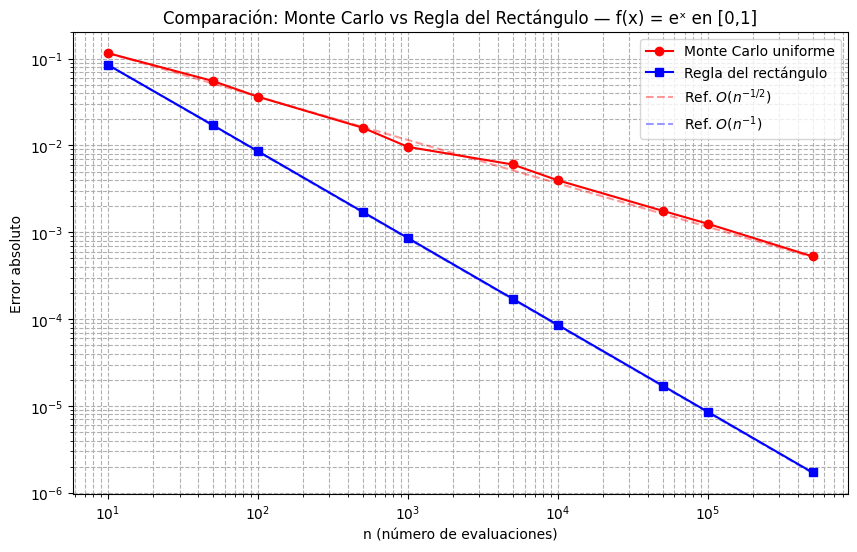


Conclusión: La regla del rectángulo, con un orden de convergencia O(n⁻¹),
converge más rápido que Monte Carlo, cuyo orden es O(n⁻¹/²).
En dimensión 1, los métodos deterministas son claramente superiores.
Sin embargo, en dimensiones altas, MC mantiene O(n⁻¹/²) independientemente de la dimensión,
mientras que los métodos deterministas sufren la 'maldición de la dimensionalidad'.


In [15]:
# EJERCICIO 18 — Comparación Monte Carlo uniforme vs regla del rectángulo

def regla_rectangulo(f, a, b, n):
    """
    Aproxima la integral de f en [a,b] usando la regla del rectángulo compuesta.
    Se evalúa f en el extremo izquierdo de cada subintervalo:
    ∫f dx ≈ h * Σ f(xᵢ), con xᵢ = a + i*h, i = 0, ..., n-1.
    """
    h = (b - a) / n
    x = np.linspace(a, a + (n - 1) * h, n)  # extremos izquierdos
    return h * np.sum(f(x))

# Función de prueba: f(x) = e^x en [0, 1], valor exacto = e - 1
f18 = lambda x: np.exp(x)
a18, b18 = 0, 1
valor_exacto_18 = np.e - 1

valores_n18 = sorted(m * 10**i for i in range(1, 6) for m in (1, 5))

errores_mc18 = []
errores_rect18 = []

print(f"{'n':>8}  {'Error MC':>12}  {'Error Rect.':>12}")
print("-" * 36)

for n18 in valores_n18:
    # MC: media de 30 ejecuciones
    res_mc = [aproximacion_integral(f18, a18, b18, n18) for _ in range(30)]
    err_mc = np.mean([abs(r - valor_exacto_18) for r in res_mc])
    
    # Regla del rectángulo (determinista)
    aprox_rect = regla_rectangulo(f18, a18, b18, n18)
    err_rect = abs(aprox_rect - valor_exacto_18)
    
    errores_mc18.append(err_mc)
    errores_rect18.append(err_rect)
    
    print(f"{n18:8d}  {err_mc:12.8f}  {err_rect:12.8f}")

# Gráfica comparativa
plt.figure(figsize=(10, 6))
plt.plot(valores_n18, errores_mc18, 'o-', color='red', label='Monte Carlo uniforme')
plt.plot(valores_n18, errores_rect18, 's-', color='blue', label='Regla del rectángulo')

# Líneas de referencia
ref_mc   = [errores_mc18[0] * (valores_n18[0]/n)**0.5 for n in valores_n18]
ref_rect = [errores_rect18[0] * (valores_n18[0]/n)**1 for n in valores_n18]
plt.plot(valores_n18, ref_mc,   '--', color='red', alpha=0.4, label=r'Ref. $O(n^{-1/2})$')
plt.plot(valores_n18, ref_rect, '--', color='blue', alpha=0.4, label=r'Ref. $O(n^{-1})$')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('n (número de evaluaciones)')
plt.ylabel('Error absoluto')
plt.title('Comparación: Monte Carlo vs Regla del Rectángulo — f(x) = eˣ en [0,1]')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.show()

print("\nConclusión: La regla del rectángulo, con un orden de convergencia O(n⁻¹),")
print("converge más rápido que Monte Carlo, cuyo orden es O(n⁻¹/²).")
print("En dimensión 1, los métodos deterministas son claramente superiores.")
print("Sin embargo, en dimensiones altas, MC mantiene O(n⁻¹/²) independientemente de la dimensión,")
print("mientras que los métodos deterministas sufren la 'maldición de la dimensionalidad'.")


In [16]:
# EJERCICIO 19 — Monte Carlo para integral doble en dominio rectangular
# Fórmula: ∫∫_D f(x,y) dxdy ≈ vol(D) * (1/n) * Σ f(xᵢ, yᵢ)
# donde (xᵢ, yᵢ) son puntos aleatorios uniformes en D = [ax,bx] × [ay,by]

def mc_integral_2d(f, ax, bx, ay, by, n):
    """
    Aproxima la integral doble de f en el rectángulo [ax,bx] × [ay,by]
    usando el método Monte Carlo con n puntos aleatorios.
    
    Parámetros:
        f       : función de dos variables f(x, y)
        ax, bx  : extremos del intervalo en x
        ay, by  : extremos del intervalo en y
        n       : número de muestras
    Devuelve:
        Aproximación de la integral doble
    """
    area = (bx - ax) * (by - ay)
    x = np.random.uniform(ax, bx, n)
    y = np.random.uniform(ay, by, n)
    return area * np.mean(f(x, y))

print("Ejercicio 19: Método Monte Carlo para integrales dobles implementado.")
print("Función mc_integral_2d(f, ax, bx, ay, by, n) disponible.")


Ejercicio 19: Método Monte Carlo para integrales dobles implementado.
Función mc_integral_2d(f, ax, bx, ay, by, n) disponible.


Aproximaciones Monte Carlo 2D (n=100000, media de 30 ejecuciones)

Función            Dominio            Aprox MC     Exacto  Error medio
----------------------------------------------------------------------
x² + y²            [0,1]×[0,1]        0.666764   0.666667     0.001184
sin(x)cos(y)       [0,π]×[0,π/2]      1.998921   2.000000     0.003386
exp(-(x²+y²))      [-1,1]×[-1,1]      2.230996   2.230985     0.001728


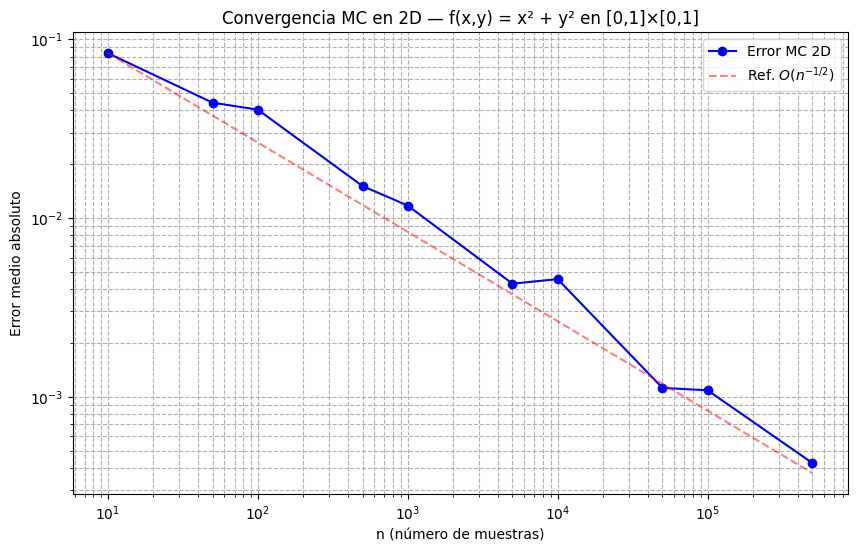


Conclusión: El método Monte Carlo se extiende de forma natural a 2D.
El orden de convergencia sigue siendo O(n⁻¹/²), igual que en 1D,
lo que es una de las grandes ventajas de MC en dimensión alta.


In [17]:
# EJERCICIO 20 — Aplicar el método MC 2D a funciones sencillas con valor exacto conocido

from scipy.integrate import dblquad

# Función 1: f(x,y) = x² + y² en [0,1] × [0,1]
# Valor exacto: ∫₀¹∫₀¹ (x² + y²) dxdy = 1/3 + 1/3 = 2/3
f20a = lambda x, y: x**2 + y**2
exacto_20a = 2/3

# Función 2: f(x,y) = sin(x) * cos(y) en [0,π] × [0,π/2]
# Valor exacto: ∫₀^π sin(x)dx * ∫₀^{π/2} cos(y)dy = 2 * 1 = 2
f20b = lambda x, y: np.sin(x) * np.cos(y)
exacto_20b = 2.0

# Función 3: f(x,y) = exp(-(x² + y²)) en [-1,1] × [-1,1]
# Valor exacto calculado numéricamente
f20c = lambda x, y: np.exp(-(x**2 + y**2))
exacto_20c, _ = dblquad(lambda y, x: np.exp(-(x**2 + y**2)), -1, 1, -1, 1)

funciones_2d = [
    (f20a, 0, 1, 0, 1, exacto_20a, "x² + y²", "[0,1]×[0,1]"),
    (f20b, 0, np.pi, 0, np.pi/2, exacto_20b, "sin(x)cos(y)", "[0,π]×[0,π/2]"),
    (f20c, -1, 1, -1, 1, exacto_20c, "exp(-(x²+y²))", "[-1,1]×[-1,1]"),
]

n20 = 100000
n_rep = 30

print(f"Aproximaciones Monte Carlo 2D (n={n20}, media de {n_rep} ejecuciones)\n")
print(f"{'Función':<18} {'Dominio':<16} {'Aprox MC':>10} {'Exacto':>10} {'Error medio':>12}")
print("-" * 70)

for f_2d, ax, bx, ay, by, exacto, nombre, dominio in funciones_2d:
    resultados = [mc_integral_2d(f_2d, ax, bx, ay, by, n20) for _ in range(n_rep)]
    media = np.mean(resultados)
    error_medio = np.mean([abs(r - exacto) for r in resultados])
    print(f"{nombre:<18} {dominio:<16} {media:10.6f} {exacto:10.6f} {error_medio:12.6f}")

# Estudio de convergencia para f(x,y) = x² + y²
valores_n20 = sorted(m * 10**i for i in range(1, 6) for m in (1, 5))
errores_2d = []

for n_val in valores_n20:
    res = [mc_integral_2d(f20a, 0, 1, 0, 1, n_val) for _ in range(n_rep)]
    errores_2d.append(np.mean([abs(r - exacto_20a) for r in res]))

plt.figure(figsize=(10, 6))
plt.plot(valores_n20, errores_2d, 'o-', color='blue', label='Error MC 2D')
ref_2d = [errores_2d[0] * (valores_n20[0]/n)**0.5 for n in valores_n20]
plt.plot(valores_n20, ref_2d, '--', color='red', alpha=0.5, label=r'Ref. $O(n^{-1/2})$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('n (número de muestras)')
plt.ylabel('Error medio absoluto')
plt.title('Convergencia MC en 2D — f(x,y) = x² + y² en [0,1]×[0,1]')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.show()

print("\nConclusión: El método Monte Carlo se extiende de forma natural a 2D.")
print("El orden de convergencia sigue siendo O(n⁻¹/²), igual que en 1D,")
print("lo que es una de las grandes ventajas de MC en dimensión alta.")
